In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal

sns.set_style("whitegrid")

# Seed para reprodutibilidade dos testes de permutação
RNG = np.random.default_rng(42)


In [2]:
from genres_mask import GENRE_BY_NAME, Genre


In [3]:
df = pd.read_parquet('db/movies.parquet')


In [4]:
def bitmask_to_list(mask: int) -> list[str]:
    l = []
    for g in Genre:
        if mask & g:
            l.append(g.name)
    return l


In [5]:
df['genres'] = df['genres'].apply(bitmask_to_list)


In [6]:
df.head()


,tconst,primaryTitle,originalTitle,startYear,genres
8,tt0000009,Miss Jerry,Miss Jerry,1894.0,[ROMANCE]
144,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,"[DOCUMENTARY, NEWS, SPORT]"
498,tt0000502,Bohemios,Bohemios,1905.0,[]
570,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,"[BIOGRAPHY, ACTION, ADVENTURE]"
587,tt0000591,The Prodigal Son,L'enfant prodigue,1907.0,[DRAMA]


In [7]:
df.info()


<class 'pandas.DataFrame'>
Index: 742013 entries, 8 to 12402706
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   tconst         742013 non-null  str    
 1   primaryTitle   742010 non-null  str    
 2   originalTitle  742010 non-null  str    
 3   startYear      630906 non-null  float64
 4   genres         742013 non-null  object 
dtypes: float64(1), object(1), str(3)
memory usage: 66.2+ MB


In [8]:
df.describe()


,startYear
count,630906.000000
mean,1994.729926
std,30.069907
min,1894.000000
25%,1977.000000
50%,2008.000000
75%,2018.000000
max,2031.000000


In [9]:
df2 = pd.read_parquet('db/ratings.parquet')

df_final = df.merge(df2)


In [10]:
df_final.head()


,tconst,primaryTitle,originalTitle,startYear,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,[ROMANCE],5.3,236
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,"[DOCUMENTARY, NEWS, SPORT]",5.3,597
2,tt0000502,Bohemios,Bohemios,1905.0,[],3.5,26
3,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,"[BIOGRAPHY, ACTION, ADVENTURE]",6.0,1065
4,tt0000591,The Prodigal Son,L'enfant prodigue,1907.0,[DRAMA],5.0,39


In [11]:
# Valores nulos por coluna
df_final.isnull().sum()


tconst            0
primaryTitle      2
originalTitle     2
startYear        36
genres            0
averageRating     0
numVotes          0
dtype: int64

In [12]:
# Remove listas vazias
df_genres = df_final[df_final["genres"].map(len) > 0].copy()

# Cria uma linha para cada gênero
df_genres = df_genres.explode("genres")

df_genres.head()


,tconst,primaryTitle,originalTitle,startYear,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,ROMANCE,5.3,236
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,DOCUMENTARY,5.3,597
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,NEWS,5.3,597
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,SPORT,5.3,597
3,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,BIOGRAPHY,6.0,1065


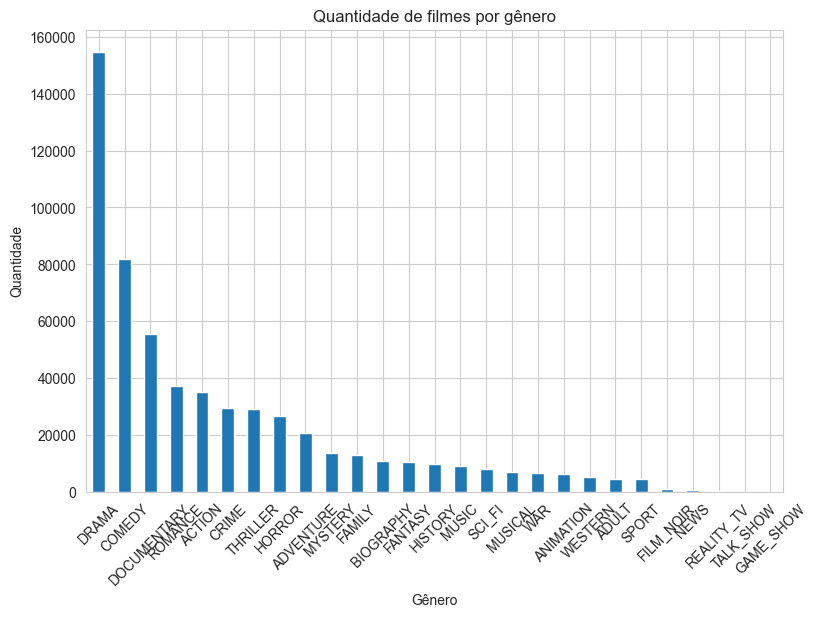

In [13]:
# Gêneros com mais filmes

genre_count = (
    df_genres["genres"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_count.plot(kind="bar")

plt.title("Quantidade de filmes por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()


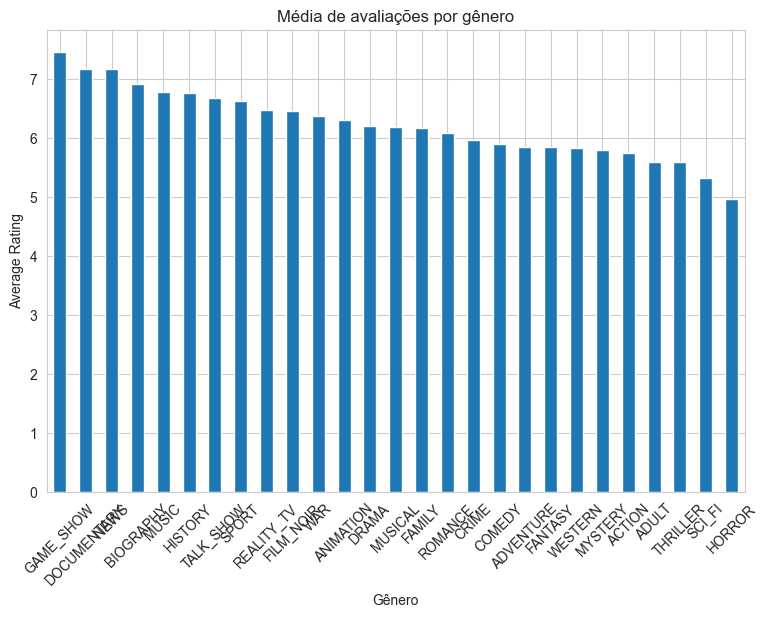

In [14]:
# Média de avaliação por gênero

genre_rating = (
    df_genres
    .groupby("genres")["averageRating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_rating.plot(kind="bar")

plt.title("Média de avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()


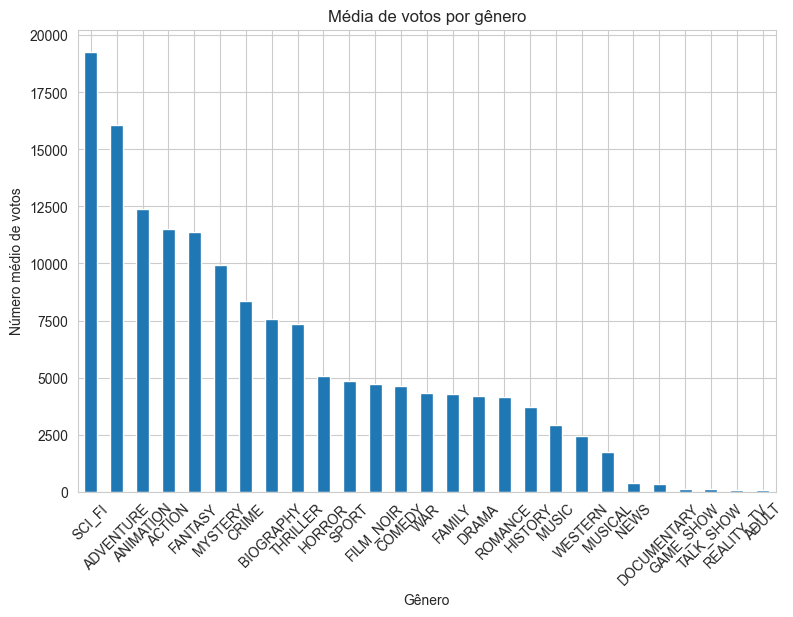

In [15]:
# Gêneros com mais engajamento

genre_votes = (
    df_genres
    .groupby("genres")["numVotes"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_votes.plot(kind="bar")

plt.title("Média de votos por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número médio de votos")

plt.xticks(rotation=45)

plt.show()


In [16]:
# Score de desempenho

genre_performance = (
    df_genres
    .groupby("genres")
    .agg({
        "averageRating": "mean",
        "numVotes": "mean"
    })
)

# Normalização simples
genre_performance["rating_norm"] = (
    genre_performance["averageRating"] /
    genre_performance["averageRating"].max()
)

genre_performance["votes_norm"] = (
    genre_performance["numVotes"] /
    genre_performance["numVotes"].max()
)

# Score final
genre_performance["performance_score"] = (
    genre_performance["rating_norm"] * 0.6 +
    genre_performance["votes_norm"] * 0.4
)

genre_performance = genre_performance.sort_values(
    by="performance_score",
    ascending=False
)

genre_performance


,averageRating,numVotes,rating_norm,votes_norm,performance_score
genres,,,,,
SCI_FI,5.332186,19278.926467,0.714132,1.000000,0.828479
ADVENTURE,5.857933,16046.443438,0.784545,0.832331,0.803659
ANIMATION,6.313121,12367.884437,0.845507,0.641524,0.763914
BIOGRAPHY,6.919357,7557.487573,0.926700,0.392008,0.712823
FANTASY,5.842920,11400.541332,0.782534,0.591347,0.706059
ACTION,5.746036,11501.961620,0.769558,0.596608,0.700378
MYSTERY,5.805572,9941.522016,0.777532,0.515668,0.672786
CRIME,5.975920,8350.736297,0.800346,0.433154,0.653469
SPORT,6.633655,4861.700184,0.888436,0.252177,0.633932


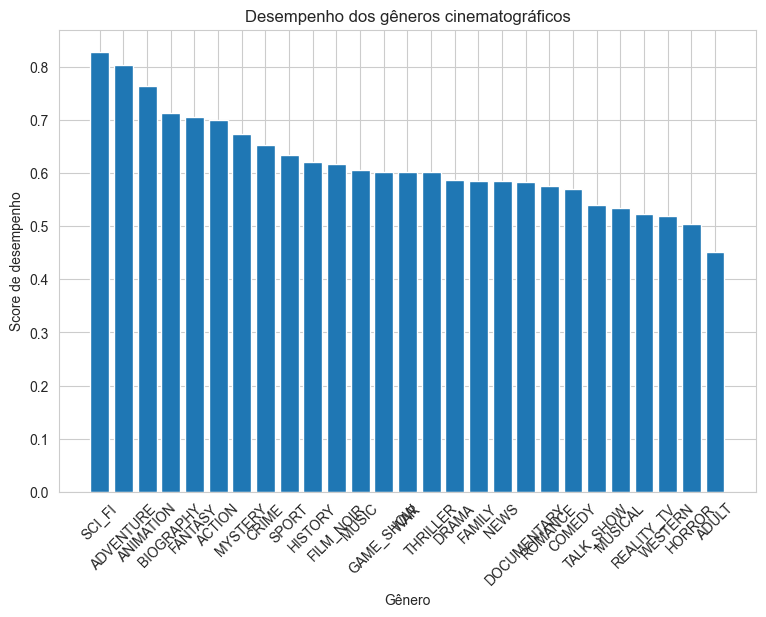

In [17]:
plt.figure(figsize=(9,6))

plt.bar(
    genre_performance.index,
    genre_performance["performance_score"]
)

plt.title("Desempenho dos gêneros cinematográficos")
plt.xlabel("Gênero")
plt.ylabel("Score de desempenho")

plt.xticks(rotation=45)

plt.show()


In [18]:
top_genres = genre_count.head(5).index

top_genres


Index(['DRAMA', 'COMEDY', 'DOCUMENTARY', 'ROMANCE', 'ACTION'], dtype='str', name='genres')

In [19]:
# BOOTSTRAP

bootstrap_results = {}

n_bootstrap = 1000

for genre in top_genres:

    ratings = df_genres[
        df_genres["genres"] == genre
    ]["averageRating"].dropna()

    means = []

    for _ in range(n_bootstrap):

        sample = ratings.sample(
            frac=1,
            replace=True
        )

        means.append(sample.mean())

    bootstrap_results[genre] = means


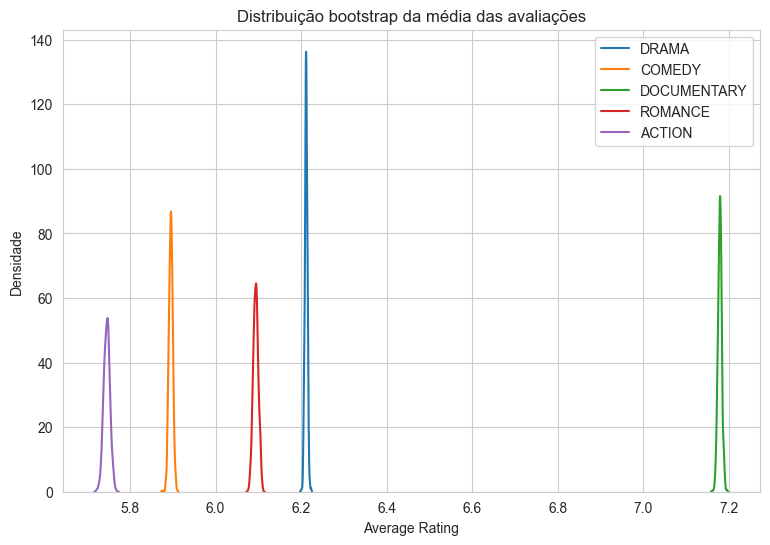

In [20]:
plt.figure(figsize=(9,6))

for genre, values in bootstrap_results.items():

    sns.kdeplot(values, label=genre)

plt.title("Distribuição bootstrap da média das avaliações")
plt.xlabel("Average Rating")
plt.ylabel("Densidade")

plt.legend()

plt.show()


In [21]:
# INTERVALO DE CONFIANÇA

confidence_intervals = []

for genre, values in bootstrap_results.items():

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    confidence_intervals.append({
        "genre": genre,
        "lower": lower,
        "upper": upper,
        "mean": np.mean(values)
    })

ci_df = pd.DataFrame(confidence_intervals)

ci_df


,genre,lower,upper,mean
0,DRAMA,6.205474,6.217543,6.211664
1,COMEDY,5.886686,5.904140,5.895329
2,DOCUMENTARY,7.169654,7.188017,7.178920
3,ROMANCE,6.082521,6.105417,6.093883
4,ACTION,5.731490,5.759714,5.745554


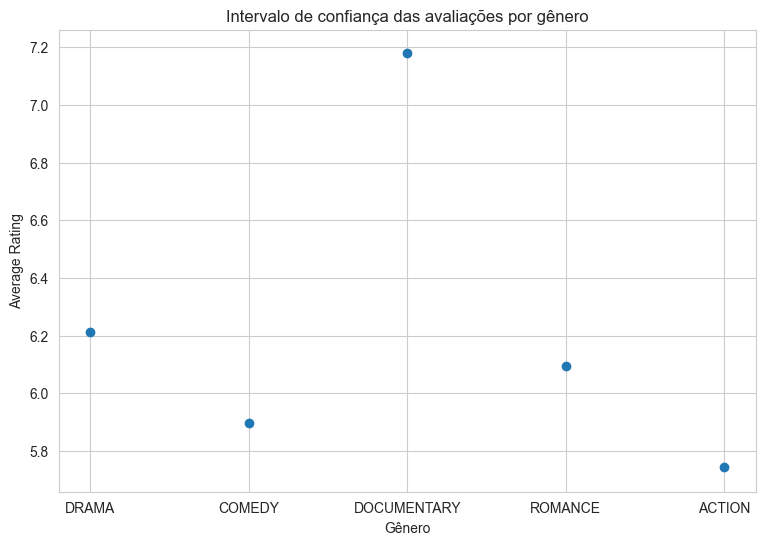

In [22]:
plt.figure(figsize=(9,6))

plt.errorbar(
    ci_df["genre"],
    ci_df["mean"],
    yerr=[
        ci_df["mean"] - ci_df["lower"],
        ci_df["upper"] - ci_df["mean"]
    ],
    fmt='o'
)

plt.title("Intervalo de confiança das avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.show()


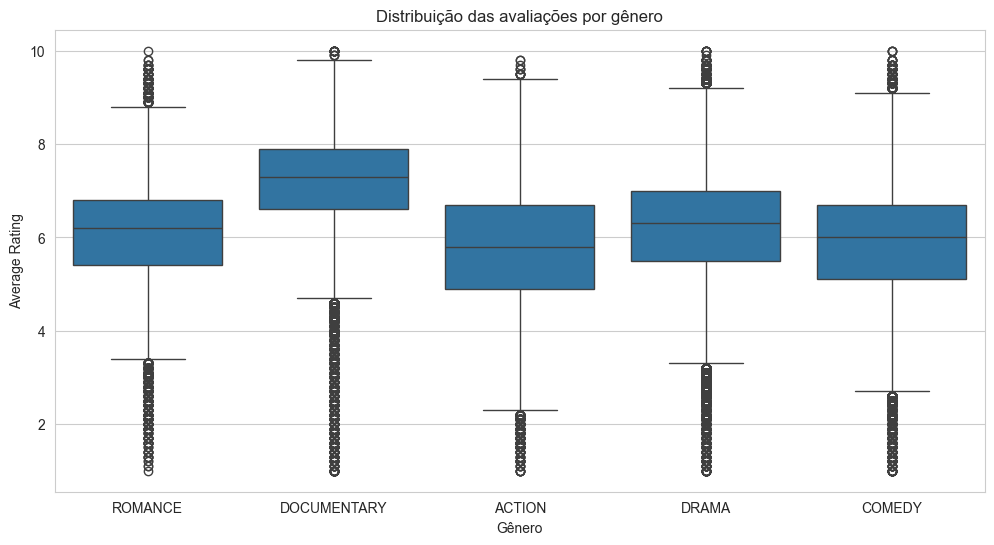

In [23]:
plot_df = df_genres[
    df_genres["genres"].isin(top_genres)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x="genres",
    y="averageRating"
)

plt.title("Distribuição das avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.show()


# Teste de hipótese: gêneros têm avaliações diferentes?

**Pergunta**: Quais gêneros apresentam melhor desempenho combinado de popularidade (votos) e avaliação (nota)?

Primeiro testamos se as notas médias dos 5 gêneros mais populares diferem entre si de forma geral (**Kruskal-Wallis**, equivalente não-paramétrico da ANOVA para mais de 2 grupos).

H0: as distribuições de `averageRating` são iguais entre os 5 gêneros mais populares.

Se houver diferença significativa, comparamos especificamente o gênero com **melhor** e o com **pior** `performance_score` via Mann-Whitney e teste de permutação.


In [24]:
# KRUSKAL-WALLIS entre os top 5 gêneros

groups = [
    plot_df[plot_df["genres"] == genre]["averageRating"].dropna()
    for genre in top_genres
]

h_stat, p_kruskal = kruskal(*groups)

print("="*60)
print("KRUSKAL-WALLIS - AVALIAÇÃO ENTRE OS 5 GÊNEROS MAIS POPULARES")
print("="*60)
print(f"\nGêneros comparados: {list(top_genres)}")
print(f"H = {h_stat:.3f}")
print(f"p-valor = {p_kruskal:.5f}")

if p_kruskal < 0.05:
    print("Conclusão: Há diferença estatisticamente significativa "
          "na avaliação entre pelo menos um dos gêneros.")
else:
    print("Conclusão: Não há diferença estatisticamente significativa "
          "na avaliação entre os gêneros.")


KRUSKAL-WALLIS - AVALIAÇÃO ENTRE OS 5 GÊNEROS MAIS POPULARES

Gêneros comparados: ['DRAMA', 'COMEDY', 'DOCUMENTARY', 'ROMANCE', 'ACTION']
H = 45008.966
p-valor = 0.00000
Conclusão: Há diferença estatisticamente significativa na avaliação entre pelo menos um dos gêneros.


In [25]:
# COMPARAÇÃO PAR A PAR: melhor x pior performance_score

best_genre = genre_performance.index[0]
worst_genre = genre_performance.index[-1]

print(f"Melhor performance_score: {best_genre}")
print(f"Pior performance_score : {worst_genre}")

ratings_best = df_genres[
    df_genres["genres"] == best_genre
]["averageRating"].dropna()

ratings_worst = df_genres[
    df_genres["genres"] == worst_genre
]["averageRating"].dropna()


Melhor performance_score: SCI_FI
Pior performance_score : ADULT


In [26]:
def permutation_test_diff_means(a, b, n_perm=10_000, rng=RNG):
    """
    Teste de permutação para diferença de médias entre dois grupos.
    H0: não há diferença entre os grupos (rótulo é irrelevante).
    Retorna a diferença observada e o p-valor bicaudal.
    """
    a = np.asarray(a)
    b = np.asarray(b)

    observed_diff = a.mean() - b.mean()

    pooled = np.concatenate([a, b])
    n_a = len(a)

    perm_diffs = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_diffs[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

    return observed_diff, p_value


In [27]:
u_stat, p_mw = mannwhitneyu(
    ratings_best,
    ratings_worst,
    alternative="two-sided"
)

diff_obs, p_perm = permutation_test_diff_means(ratings_best, ratings_worst)

print("="*60)
print(f"{best_genre} x {worst_genre}")
print("="*60)
print(f"\nMédia {best_genre} : {ratings_best.mean():.3f}")
print(f"Média {worst_genre} : {ratings_worst.mean():.3f}")
print(f"Diferença observada: {diff_obs:.3f}")
print(f"\nMann-Whitney        : p = {p_mw:.5f}")
print(f"Permutação (10.000) : p = {p_perm:.5f}")

if p_mw < 0.05:
    print("\nConclusão: A diferença entre os dois gêneros é "
          "estatisticamente significativa.")
else:
    print("\nConclusão: A diferença entre os dois gêneros não é "
          "estatisticamente significativa.")


SCI_FI x ADULT

Média SCI_FI : 5.332
Média ADULT : 5.599
Diferença observada: -0.266

Mann-Whitney        : p = 0.00000
Permutação (10.000) : p = 0.00000

Conclusão: A diferença entre os dois gêneros é estatisticamente significativa.
